# KAN 可符号化实验（symkan 重构版）

本 notebook 对应论文中的完整实验链路，目标是同时获得：
- 可接受的分类性能（accuracy / AUC）
- 可解释的符号表达式（分层函数库 + 逐层符号化）
- 可复现的性能基准（耗时/内存/并行策略）

## 实验主线
1. 数据读取与设备统一
2. baseline KAN 与输入归因筛选
3. 分阶段稀疏训练（stagewise）
4. 分层符号化导出（含低风险提速开关）
5. 数值验证 + ROC/AUC + 结构化导出
6. 速度与内存基准（含多轮统计）

## 关键原则
- 符号化采用**分层策略**，不跨层联合拟合。
- 默认优先稳定性，再通过并行与门控参数提升速度。
- 典型 2 层 KAN 默认关闭 LayerwiseFT（`layerwise_finetune_steps=0`），只在对照实验中按需开启。
- 所有核心结果均导出为 CSV，便于论文复用。

In [1]:
import os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import torch
from sklearn.metrics import accuracy_score

cwd = Path.cwd().resolve()
repo_candidates = [cwd, cwd.parent]
repo_root = next(
    (
        candidate.resolve()
        for candidate in repo_candidates
        if (candidate / 'symkan').exists() and (candidate / 'kan').exists()
    ),
    cwd,
)
notebook_root = repo_root / 'notebooks'
notebook_output_dir = repo_root / 'outputs' / 'notebooks'
notebook_output_dir.mkdir(parents=True, exist_ok=True)
if Path.cwd().resolve() != notebook_root:
    os.chdir(notebook_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

warnings.filterwarnings('ignore')
np.random.seed(123)
torch.manual_seed(123)

from kan import KAN

# notebook initial device (normalized again in symkan setup cells)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('cwd =', cwd)
print('notebook_root =', notebook_root)
print('notebook_output_dir =', notebook_output_dir)
print('repo_root =', repo_root)
print('device =', device)


cwd = D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\notebooks
notebook_root = D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\notebooks
notebook_output_dir = D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\outputs\notebooks
repo_root = D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments
device = cpu


## 1) 数据读取与任务定义

- 优先读取本地：`X_train/X_test` 与 `Y_train_cat/Y_test_cat`。
- 若本地文件缺失，自动按 SymbolNet 思路获取 MNIST 并预处理后落盘。
- 自动兼容 one-hot 与类别索引标签格式。
- 输出统一得到 `n_classes` 与 `input_dim`，作为后续建模参数。

In [2]:
from pathlib import Path
import numpy as np
from sklearn.datasets import fetch_openml


def _select_classes(x, y, classes):
    mask = np.zeros_like(y, dtype=bool)
    for c in classes:
        mask |= (y == c)
    return x[mask], y[mask]


def _onehot_from_labels(y, classes):
    classes = sorted(set(int(v) for v in classes))
    mapping = {c: i for i, c in enumerate(classes)}
    idx = np.array([mapping[int(v)] for v in y], dtype=np.int64)
    return np.eye(len(classes), dtype=np.float32)[idx]


def _fetch_mnist_symbolnet_style(classes):
    # 优先使用 SymbolNet 的 keras.mnist 路径；不可用时回退到 openml。
    try:
        from tensorflow import keras  # type: ignore
        (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
        x_train = x_train.reshape(x_train.shape[0], -1).astype(np.float32) / 255.0
        x_test = x_test.reshape(x_test.shape[0], -1).astype(np.float32) / 255.0
        y_train = y_train.astype(np.int64)
        y_test = y_test.astype(np.int64)
        source = 'tensorflow.keras.datasets.mnist'
    except Exception:
        mnist = fetch_openml('mnist_784', version=1, as_frame=False)
        x = mnist.data.astype(np.float32) / 255.0
        y = mnist.target.astype(np.int64)
        x_train, x_test = x[:60000], x[60000:]
        y_train, y_test = y[:60000], y[60000:]
        source = 'sklearn.fetch_openml(mnist_784)'

    x_train, y_train = _select_classes(x_train, y_train, classes)
    x_test, y_test = _select_classes(x_test, y_test, classes)
    y_train_oh = _onehot_from_labels(y_train, classes)
    y_test_oh = _onehot_from_labels(y_test, classes)
    return x_train, x_test, y_train_oh, y_test_oh, source


x_train_path = repo_root / 'data' / 'X_train.npy'
x_test_path = repo_root / 'data' / 'X_test.npy'
y_train_path = repo_root / 'data' / 'Y_train_cat.npy'
y_test_path = repo_root / 'data' / 'Y_test_cat.npy'

if all(p.exists() for p in [x_train_path, x_test_path, y_train_path, y_test_path]):
    X_train = np.load(x_train_path).astype(np.float32)
    X_test = np.load(x_test_path).astype(np.float32)
    Y_train_raw = np.load(y_train_path)
    Y_test_raw = np.load(y_test_path)
    print('已从本地加载 npy 数据文件。')
else:
    classes = list(range(10))
    X_train, X_test, Y_train_raw, Y_test_raw, source = _fetch_mnist_symbolnet_style(classes)
    np.save(x_train_path, X_train.astype(np.float32))
    np.save(x_test_path, X_test.astype(np.float32))
    np.save(y_train_path, Y_train_raw.astype(np.float32))
    np.save(y_test_path, Y_test_raw.astype(np.float32))
    print(f'检测到缺失数据文件，已自动生成并保存（source={source}, classes={classes}）。')

if Y_train_raw.ndim > 1:
    y_train = np.argmax(Y_train_raw, axis=1).astype(np.int64)
    y_test = np.argmax(Y_test_raw, axis=1).astype(np.int64)
    n_classes = int(Y_train_raw.shape[1])
else:
    y_train = Y_train_raw.astype(np.int64)
    y_test = Y_test_raw.astype(np.int64)
    n_classes = int(np.max(y_train) + 1)

Y_train = np.eye(n_classes, dtype=np.float32)[y_train]
Y_test = np.eye(n_classes, dtype=np.float32)[y_test]

input_dim = X_train.shape[1]
print(f'X_train: {X_train.shape}  Y_train: {Y_train.shape}')
print(f'X_test : {X_test.shape}   Y_test : {Y_test.shape}')
print(f'n_classes = {n_classes}, input_dim = {input_dim}')

已从本地加载 npy 数据文件。
X_train: (60000, 784)  Y_train: (60000, 10)
X_test : (10000, 784)   Y_test : (10000, 10)
n_classes = 10, input_dim = 784


## 2) 运行时与基础工具初始化

本节完成：
- `symkan` 分层 API 导入
- 设备归一化（CPU/CUDA）
- 批大小策略统一（`default_batch_size`）

说明：后续所有训练、符号化与评估都复用这里的运行时配置。

In [3]:
# 使用分层后的 symkan API
import importlib
import symkan.core.runtime as core_runtime
importlib.reload(core_runtime)

from symkan.core import (
    set_device,
    get_device,
    build_dataset,
    model_logits,
    model_acc,
    model_acc_ds,
    get_n_edge,
    safe_fit,
)
from symkan.pruning import safe_attribute

resolve_device = core_runtime.resolve_device
default_batch_size = core_runtime.default_batch_size

# 归一化设备并同步到 symkan 运行时
device = str(resolve_device(device))
set_device(device)
BATCH_SIZE = default_batch_size()

print('symkan.core/pruning 已加载 ✓')
print('当前设备 =', get_device())
print('BATCH_SIZE =', BATCH_SIZE)

symkan.core/pruning 已加载 ✓
当前设备 = cpu
BATCH_SIZE = 64


## 3) 训练与符号化组件准备

加载三类核心组件：
- `tuning`：阶段训练与模型选择
- `symbolic`：分层符号化与表达式处理
- `eval/io`：数值验证、AUC 与报表导出

从本节开始进入可执行实验主流程。

In [4]:
# 使用 symkan.tuning 的分阶段训练模块
from symkan.tuning import sym_readiness_score
from symkan.notebook_compat import stagewise_train_from_notebook as stagewise_train

print('stagewise_train 已切换到 notebook compat 包装器 ✓')
print('sym_readiness_score 已从 symkan.tuning 加载 ✓')

stagewise_train 已切换到 notebook compat 包装器 ✓
sym_readiness_score 已从 symkan.tuning 加载 ✓


In [5]:
# 使用 symkan.symbolic / symkan.eval / symkan.io
from symkan.symbolic import (
    format_expr,
    LIB_HIDDEN,
    LIB_OUTPUT,
    collect_all_formulas,
)
from symkan.notebook_compat import symbolize_pipeline_from_notebook as symbolize_pipeline
from symkan.eval import (
    validate_formula_numerically,
    compute_multiclass_roc_auc,
    plot_roc_curves,
)
from symkan.io import save_symbolic_summary

# 保留 notebook 历史变量名兼容
_LIB_HIDDEN = LIB_HIDDEN
_LIB_OUTPUT = LIB_OUTPUT

print('='*60)
print('symbolic/eval/io 已切换到分层 API + notebook compat ✓')
print(f'  _LIB_HIDDEN = {_LIB_HIDDEN}')
print(f'  _LIB_OUTPUT = {_LIB_OUTPUT}')

symbolic/eval/io 已切换到分层 API + notebook compat ✓
  _LIB_HIDDEN = ['x', 'x^2', 'tanh']
  _LIB_OUTPUT = ['x', 'x^2']


## 4) Baseline KAN（对照组）

目标：给出未强化流程下的基准精度与边数。
- 采用较窄网络与 `grid=5`，保证后续符号化可行。
- 该结果用于与增强模型、符号化模型做公平对比。

## 4) CNN 特征提取（784 → 50）

在进入 KAN 之前，先用一个小型 CNN 学习图像表征，并导出 50 维特征向量。
后续 KAN 的训练、归因和符号化都基于该特征空间进行。


In [6]:
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

CNN_FEATURE_DIM = 50
CNN_EPOCHS = 6 if str(device).startswith('cuda') else 4
CNN_BATCH = 256 if str(device).startswith('cuda') else 128
CNN_LR = 1e-3
CNN_SEED = 123

feat_train_path = repo_root / 'data' / f'X_train_cnn{CNN_FEATURE_DIM}.npy'
feat_test_path = repo_root / 'data' / f'X_test_cnn{CNN_FEATURE_DIM}.npy'

if feat_train_path.exists() and feat_test_path.exists():
    X_train_cnn = np.load(feat_train_path).astype(np.float32)
    X_test_cnn = np.load(feat_test_path).astype(np.float32)
    print(f'Loaded cached CNN features: train={X_train_cnn.shape}, test={X_test_cnn.shape}')
else:
    torch.manual_seed(CNN_SEED)
    np.random.seed(CNN_SEED)

    class SmallMnistCnn(nn.Module):
        def __init__(self, feature_dim: int, num_classes: int):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )
            self.project = nn.Sequential(
                nn.Flatten(),
                nn.Linear(32 * 7 * 7, 128),
                nn.ReLU(),
                nn.Linear(128, feature_dim),
                nn.ReLU(),
            )
            self.classifier = nn.Linear(feature_dim, num_classes)

        def forward(self, x, return_feature: bool = False):
            h = self.features(x)
            z = self.project(h)
            logits = self.classifier(z)
            if return_feature:
                return logits, z
            return logits

    train_img = torch.from_numpy(X_train.reshape(-1, 1, 28, 28)).float()
    test_img = torch.from_numpy(X_test.reshape(-1, 1, 28, 28)).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    y_test_tensor = torch.from_numpy(y_test).long()

    train_loader = DataLoader(
        TensorDataset(train_img, y_train_tensor),
        batch_size=CNN_BATCH,
        shuffle=True,
        num_workers=0,
    )
    test_loader = DataLoader(
        TensorDataset(test_img, y_test_tensor),
        batch_size=CNN_BATCH,
        shuffle=False,
        num_workers=0,
    )

    cnn_model = SmallMnistCnn(feature_dim=CNN_FEATURE_DIM, num_classes=n_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR, weight_decay=1e-4)

    for epoch in range(1, CNN_EPOCHS + 1):
        cnn_model.train()
        running_loss = 0.0
        running_correct = 0
        seen = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = cnn_model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            running_correct += (logits.argmax(dim=1) == yb).sum().item()
            seen += yb.size(0)

        train_loss = running_loss / max(1, seen)
        train_acc = running_correct / max(1, seen)

        cnn_model.eval()
        test_correct = 0
        test_seen = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = cnn_model(xb)
                test_correct += (logits.argmax(dim=1) == yb).sum().item()
                test_seen += yb.size(0)
        test_acc = test_correct / max(1, test_seen)
        print(f'[CNN] epoch {epoch}/{CNN_EPOCHS} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | test_acc={test_acc:.4f}')

    def extract_cnn_feature(np_x: np.ndarray) -> np.ndarray:
        loader = DataLoader(
            TensorDataset(torch.from_numpy(np_x.reshape(-1, 1, 28, 28)).float()),
            batch_size=CNN_BATCH,
            shuffle=False,
            num_workers=0,
        )
        feats = []
        cnn_model.eval()
        with torch.no_grad():
            for (xb,) in loader:
                xb = xb.to(device)
                _, z = cnn_model(xb, return_feature=True)
                feats.append(z.detach().cpu())
        return torch.cat(feats, dim=0).numpy().astype(np.float32)

    X_train_cnn = extract_cnn_feature(X_train)
    X_test_cnn = extract_cnn_feature(X_test)

    feat_mean = X_train_cnn.mean(axis=0, keepdims=True)
    feat_std = X_train_cnn.std(axis=0, keepdims=True) + 1e-6
    X_train_cnn = ((X_train_cnn - feat_mean) / feat_std).astype(np.float32)
    X_test_cnn = ((X_test_cnn - feat_mean) / feat_std).astype(np.float32)

    np.save(feat_train_path, X_train_cnn)
    np.save(feat_test_path, X_test_cnn)
    print(f'Saved CNN features to: {feat_train_path} and {feat_test_path}')

X_train_kan = X_train_cnn
X_test_kan = X_test_cnn
input_dim_kan = int(X_train_kan.shape[1])
print(f'KAN input switched to CNN features: train={X_train_kan.shape}, test={X_test_kan.shape}, input_dim_kan={input_dim_kan}')



[CNN] epoch 1/4 | loss=0.3286 | train_acc=0.9008 | test_acc=0.9657
[CNN] epoch 2/4 | loss=0.0850 | train_acc=0.9739 | test_acc=0.9805
[CNN] epoch 3/4 | loss=0.0588 | train_acc=0.9822 | test_acc=0.9867
[CNN] epoch 4/4 | loss=0.0458 | train_acc=0.9858 | test_acc=0.9854
Saved CNN features to: D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\data\X_train_cnn50.npy and D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\data\X_test_cnn50.npy
KAN input switched to CNN features: train=(60000, 50), test=(10000, 50), input_dim_kan=50


In [21]:
dataset_full = build_dataset(X_train_kan, Y_train, X_test_kan, Y_test)

# Two-layer KAN on CNN feature space
inner_dim = 16
width_base = [input_dim_kan, inner_dim, n_classes]

base_model = KAN(
    width=width_base, grid=5, k=3, seed=123,
    auto_save=False, symbolic_enabled=True, save_act=True, device=device,
)

# Stage A: coarse fitting + mild sparsity
base_res = safe_fit(
    base_model, dataset_full,
    opt='Adam', steps=200, lr=0.005, lamb=1e-4,
    batch=BATCH_SIZE, update_grid=True, singularity_avoiding=True, log=12,
)




base_acc = model_acc(base_model, X_test_kan, y_test)
print(f'\nBaseline KAN (CNN feature) test accuracy = {base_acc:.4f}')
print(f'Baseline n_edge = {get_n_edge(base_model)}')



| train_loss: 6.57e-02 | test_loss: 7.73e-02 | reg: 3.45e+01 | : 100%|█| 200/200 [00:04<00:00, 46.28



Baseline KAN (CNN feature) test accuracy = 0.9849
Baseline n_edge = 960


## 5) 归因式输入筛选（降维）

目标：在精度可控前提下减少输入维度，提高符号化稳定性与速度。
- 使用 `safe_attribute` 计算特征贡献。
- 保留 top-K 特征并重建训练/测试数据集。
- 该步骤通常显著影响后续符号化耗时。

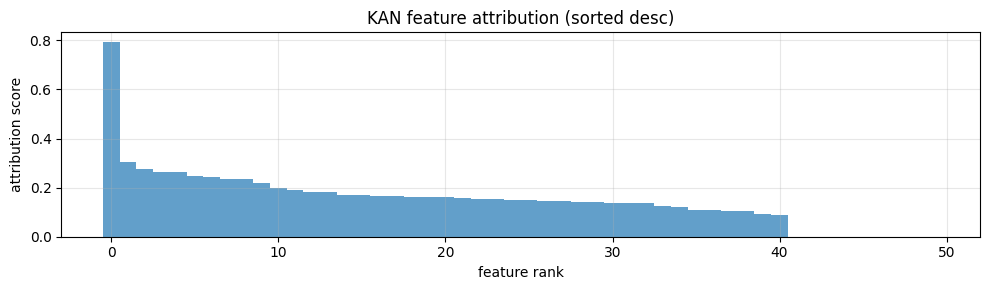

Input dim: 50 -> 50
Min attribution among kept features: 0.26284
Kept feature indices (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]...
dataset_enhanced train shape: (60000, 50)
dataset_enhanced test shape:  (10000, 50)


In [23]:
# 【Key】Refresh feature attribution on CNN features
feature_score = safe_attribute(base_model, dataset_full)

# Visualization
plt.figure(figsize=(10, 3))
plt.title('KAN feature attribution (sorted desc)')
sorted_scores = np.sort(feature_score)[::-1]
plt.bar(range(len(sorted_scores)), sorted_scores, width=1.0, alpha=0.7)
plt.xlabel('feature rank')
plt.ylabel('attribution score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Select top-K features from CNN feature space
top_k = min(50, input_dim_kan)
keep_idx = np.sort(np.argsort(-feature_score)[:top_k])

print(f'Input dim: {input_dim_kan} -> {len(keep_idx)}')
print(f'Min attribution among kept features: {feature_score[keep_idx[-1]]:.5f}')
print(f'Kept feature indices (first 20): {keep_idx.tolist()[:20]}...')

# Build reduced dataset
X_train_sel = X_train_kan[:, keep_idx]
X_test_sel  = X_test_kan[:, keep_idx]
dataset_enhanced = build_dataset(X_train_sel, Y_train, X_test_sel, Y_test)

print(f'dataset_enhanced train shape: {X_train_sel.shape}')
print(f'dataset_enhanced test shape:  {X_test_sel.shape}')



## 6) 增强模型训练（阶段稀疏化 + 渐进剪枝）

目标：得到“精度-稀疏度”折中最优的候选模型。
- 通过 `stagewise_train` 在多个阶段中自动选择得分最优快照。
- 输出 `selected_stage/selected_score` 作为后续符号化入口。

In [24]:
sel_dim = dataset_enhanced['train_input'].shape[1]
width_enh = [sel_dim, inner_dim, n_classes]
print(f'Enhanced KAN 结构: {width_enh}  (grid=5, k=3)')
print(f'理论满连接边数: {sel_dim*inner_dim + inner_dim*n_classes}')

# 启发式评分选择 + 自适应符号化
enhanced_model, enhanced_res = stagewise_train(
    dataset_enhanced, width=width_enh,
    grid=5, k=3, seed=42,
    # 更多更细的稀疏化阶段（10 个 stage，λ 缓慢递增）
    lamb_schedule=(0.0, 0.0, 2e-5, 5e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3),
    lr_schedule  =(0.02, 0.015, 0.012, 0.01, 0.008, 0.006, 0.005, 0.004, 0.003, 0.002),
    steps_per_stage=60,
    batch_size=BATCH_SIZE,
    prune_start_stage=3,          # 前 3 个 stage 只训练不剪枝
    target_edges=120,              # 放宽目标，给符号化更多余量
    prune_edge_threshold_init=0.003,  # 从非常小的阈值开始
    prune_edge_threshold_step=0.003,  # 每次小幅递增
    prune_acc_drop_tol=0.04,      # 容忍 4% 精度下降
    post_prune_ft_steps=50,       # 每次剪枝后微调 50 步
    sym_target_edges=50,          # 符号化目标边数（用于评分）
    acc_weight=0.5,               # 精度权重 ，稀疏度权重 = 1 - acc_weight
    verbose=True,
 )

enhanced_acc = model_acc_ds(enhanced_model, dataset_enhanced)
print(f'\nEnhanced KAN test accuracy = {enhanced_acc:.4f}')
print(f'Enhanced n_edge = {get_n_edge(enhanced_model)}')
print(f'Selected stage = {enhanced_res["selected_stage"]}')
print(f'Selected score = {enhanced_res["selected_score"]:.3f}')

# 显示所有 stage 的评分排名
stage_df = pd.DataFrame(enhanced_res['stage_logs'])
display(stage_df)

# v4: 评分排名可视化
print(f'\n所有 stage 综合评分排名:')
snapshots_info = [
    {'stage': s['stage'], 'acc': s['acc'], 'edges': s['n_edges'], 'score': s['score']}
    for s in enhanced_res['stage_snapshots']
]
rank_df = pd.DataFrame(snapshots_info).sort_values('score', ascending=False)
display(rank_df)

Enhanced KAN 结构: [50, 16, 10]  (grid=5, k=3)
理论满连接边数: 960


| train_loss: 6.88e-02 | test_loss: 8.58e-02 | reg: 0.00e+00 | : 100%|█| 60/60 [00:01<00:00, 43.25it


[stage 0] λ=0.0e+00 lr=0.0200  acc 0.0831→0.9832  edges 960→960  score=0.518  prune=✗  


| train_loss: 7.08e-02 | test_loss: 6.83e-02 | reg: 0.00e+00 | : 100%|█| 60/60 [00:00<00:00, 63.48it


[stage 1] λ=0.0e+00 lr=0.0150  acc 0.9832→0.9841  edges 960→960  score=0.518  prune=✗  


...

| train_loss: 5.76e-02 | test_loss: 6.37e-02 | reg: 0.00e+00 | : 100%|█| 60/60 [00:00<00:00, 69.41it



──────────────────────────────────────────────────
模型选择（sym_readiness_score, acc_weight=0.5）:
  精度下限: 0.6406 (max_acc=0.9856 × 0.65)
  候选数量: 11/11
  ▸ 选中 stage=final, acc=0.9817, edges=102, score=0.736

Enhanced KAN test accuracy = 0.9817
Enhanced n_edge = 102
Selected stage = final
Selected score = 0.736


,stage,lamb,effective_lamb,lr,acc_before,acc_after,edges_before,edges_after,prune_accepted,prune_attempts,prune_attempt_count,guard_mode,fit_success,fit_error,rollback,prune_th,sym_score,train_seconds,prune_seconds,stage_seconds
0,0,0.00000,0.00000,0.020,0.0831,0.9832,960,960,False,[],0,light,True,None,,0.003,0.517642,1.392912,0.000000,2.100488
1,1,0.00000,0.00000,0.015,0.9832,0.9841,960,960,False,[],0,light,True,None,,0.003,0.518092,0.948276,0.000000,1.611523
2,2,0.00002,0.00002,0.012,0.9841,0.9845,960,960,False,[],0,light,True,None,,0.003,0.518292,1.323369,0.000000,1.982910
3,3,0.00005,0.00005,0.010,0.9845,0.9845,960,622,True,"[{'attempt': 0, 'threshold': 0.003, 'success':...",1,light,True,None,,0.006,0.532443,1.412857,1.764792,3.881582
4,4,0.00010,0.00010,0.008,0.9845,0.9856,622,369,True,"[{'attempt': 0, 'threshold': 0.006, 'success':...",1,light,True,None,,0.009,0.560551,1.249328,1.608416,3.455982
5,5,0.00020,0.00020,0.006,0.9856,0.9834,369,194,True,"[{'attempt': 0, 'threshold': 0.009000000000000...",1,light,True,None,,0.012,0.620566,1.237704,1.688389,3.505896
6,6,0.00030,0.00030,0.005,0.9834,0.9818,194,136,True,"[{'attempt': 0, 'threshold': 0.012, 'success':...",1,light,True,None,,0.015,0.674724,1.222109,1.699743,3.508112
7,7,0.00050,0.00050,0.004,0.9818,0.9809,136,102,True,"[{'attempt': 0, 'threshold': 0.015, 'success':...",1,light,True,None,,0.018,0.735548,1.263519,1.678030,3.548186
8,8,0.00070,0.00070,0.003,0.9809,0.9807,102,102,False,[],0,light,True,None,,0.018,0.735448,1.212382,0.000000,1.810729
9,9,0.00100,0.00100,0.002,0.9807,0.9808,102,102,False,[],0,light,True,None,,0.018,0.735498,1.265655,0.000000,1.884169



所有 stage 综合评分排名:


,stage,acc,edges,score
10,final,0.9817,102,0.735948
7,7,0.9809,102,0.735548
9,9,0.9808,102,0.735498
8,8,0.9807,102,0.735448
6,6,0.9818,136,0.674724
5,5,0.9834,194,0.620566
4,4,0.9856,369,0.560551
3,3,0.9845,622,0.532443
2,2,0.9845,960,0.518292
1,1,0.9841,960,0.518092


## 7) 训练结果可视化与摘要

本节用于快速检查训练质量：
- baseline vs enhanced 的损失曲线
- 阶段边数变化
- 核心指标摘要表（精度、边数）

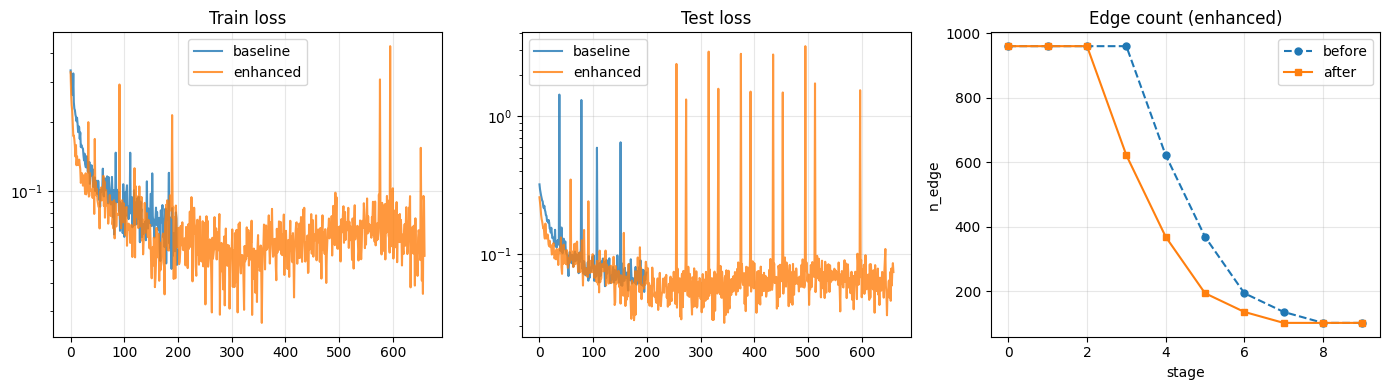

,model,input_dim,test_acc,n_edge,best_acc
0,baseline_kan,50,0.9849,960,NaN
1,enhanced_kan,50,0.9817,102,0.9817


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curves
ax = axes[0]
ax.set_title('Train loss')
if 'train_loss' in base_res:
    ax.plot(base_res['train_loss'], label='baseline', alpha=0.8)
ax.plot(enhanced_res['train_loss'], label='enhanced', alpha=0.8)
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.set_title('Test loss')
if 'test_loss' in base_res:
    ax.plot(base_res['test_loss'], label='baseline', alpha=0.8)
ax.plot(enhanced_res['test_loss'], label='enhanced', alpha=0.8)
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3)

# Edge count per stage
ax = axes[2]
ax.set_title('Edge count (enhanced)')
if len(stage_df) > 0:
    ax.plot(stage_df['stage'], stage_df['edges_before'], 'o--', label='before', ms=5)
    ax.plot(stage_df['stage'], stage_df['edges_after'], 's-', label='after', ms=5)
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('stage')
    ax.set_ylabel('n_edge')

plt.tight_layout()
plt.show()

# 汇总表
summary = pd.DataFrame([
    {
        'model': 'baseline_kan',
        'input_dim': int(input_dim_kan) if 'input_dim_kan' in globals() else int(input_dim),
        'test_acc': float(base_acc),
        'n_edge': get_n_edge(base_model),
    },
    {
        'model': 'enhanced_kan',
        'input_dim': int(enhanced_model.width_in[0]) if hasattr(enhanced_model, 'width_in') else '?',
        'test_acc': float(enhanced_acc),
        'n_edge': get_n_edge(enhanced_model),
        'best_acc': float(enhanced_res.get('best_acc', enhanced_acc)),
    }
])
summary


## 8) 符号化导出（主实验）

本节是核心导出流程：
1. 渐进剪枝（边数收缩）
2. 逐层符号拟合（不跨层）
3. 层间/全局微调（含低风险提速开关）
4. 表达式收集与统计输出

关键观察项：
- `final_acc`、`final_n_edge`
- `sym_stats`（活跃边/fix/低R²）
- `timing`（symbolic_total_seconds 与 layer times）

In [26]:
print('='*60)
print('符号化导出 — 强制全符号化 + 数值安全函数库 + 分层')
print('='*60)
print(f'选中模型: stage={enhanced_res["selected_stage"]}, '
      f'边数={get_n_edge(enhanced_model)}, '
      f'精度={enhanced_acc:.4f}, '
      f'评分={enhanced_res["selected_score"]:.3f}')

t0 = time.time()
export_result = symbolize_pipeline(
    enhanced_model, dataset_enhanced,
    target_edges=90,              # 符号化目标边数，过高可能导致符号化失败，过低可能过度简化，需根据实际情况调整
    max_prune_rounds=30,
    lib=None,                       # 不指定统一库，使用分层库
    lib_hidden=_LIB_HIDDEN,         # 输入→隐藏层
    lib_output=_LIB_OUTPUT,         # 隐藏→输出层
    weight_simple=0.10,             # weight_simple×复杂度 + (1-weight_simple)×R²损失，weight越大越偏好简单函数
    finetune_steps=50,              # 稀疏化微调50步
    finetune_lr=0.0005,             # 稀疏化微调学习率
    layerwise_finetune_steps=0,     # 2层KAN默认关闭LayerwiseFT；需要时再按改进版参数开启
    affine_finetune_steps=200,      # 200步强化微调，补偿全符号化精度损失
    affine_finetune_lr_schedule=[0.003, 0.001, 0.0005, 0.0002],  # 强化微调学习率逐步降低
    parallel_mode='auto',           # auto: CPU并行建议，CUDA默认串行
    parallel_workers=None,          # None时自动推断
    parallel_min_tasks=16,          # 任务数不足时退回串行，避免并行开销
    # 低风险提速：剪枝阶段评估门控 + 归因采样分级 + 强化微调早停
    prune_eval_interval=2,                  # 每2轮评估一次，接近目标边数时自动恢复逐轮评估
    prune_attr_sample_adaptive=True,
    prune_attr_sample_min=768,
    prune_attr_sample_max=2048,
    heavy_ft_early_stop_patience=2,         # 若连续patience次提升小于min_delta，提前结束后续重微调步骤
    heavy_ft_early_stop_min_delta=5e-4,
    collect_timing=True,                    # 返回分阶段耗时统计
    batch_size=BATCH_SIZE,
    verbose=True,
 )
export_time = time.time() - t0

export_model    = export_result['model']
export_formulas = export_result['formulas']
valid_exprs     = export_result['valid_expressions']
export_trace    = export_result['trace']
sym_stats       = export_result['sym_stats']
timing_stats    = export_result.get('timing', {})

print(f'\n导出完成 (耗时 {export_time:.1f}s)')
print(f'输入边数: {export_result.get("input_n_edge", "N/A")} → '
      f'自适应目标: {export_result.get("effective_target_edges", "N/A")} → '
      f'最终边数: {export_result["final_n_edge"]}')
print(f'符号化后精度: {export_result.get("final_acc", "N/A")}')

input_dim_before = int(dataset_enhanced['train_input'].shape[1])
effective_input_dim = int(export_result.get('effective_input_dim', input_dim_before))
compress_ratio = (1.0 - effective_input_dim / max(1, input_dim_before)) * 100.0
print(f'有效输入维度: {effective_input_dim}/{input_dim_before}')
print(f'输入压缩比例: {compress_ratio:.2f}%')

print(f'符号化统计: 活跃边 {sym_stats.get("total",0)}, '
      f'fix成功 {sym_stats.get("fixed",0)}, '
      f'低R²强制fix {sym_stats.get("low_r2",0)}')
print(f'有效表达式数量: {len(valid_exprs)}')
print(f'并行suggest workers: {sym_stats.get("parallel_workers", 1)}')

if timing_stats:
    print('\n耗时统计摘要:')
    print(f"  - symbolic_total_seconds = {timing_stats.get('symbolic_total_seconds', 'N/A')}")
    if timing_stats.get('symbolic_layers'):
        print('  - layer times:')
        for rec in timing_stats['symbolic_layers'][:6]:
            print(f"    layer={rec['layer']}, active={rec['active']}, fixed={rec['fixed']}, t={rec['seconds']:.3f}s, workers={rec['workers']}")

# 显示R²分布
r2_recs = sym_stats.get('r2_records', [])
if r2_recs:
    r2_vals = [r['r2'] for r in r2_recs]
    print(f'\n逐边R²分布:')
    print(f'  min={min(r2_vals):.4f}, median={np.median(r2_vals):.4f}, max={max(r2_vals):.4f}')
    n_low = sum(1 for v in r2_vals if v < 0.5)
    print(f'  R² < 0.5 (低R²强制fix): {n_low}/{len(r2_vals)}')
    from collections import Counter
    name_counts = Counter(r['name'] for r in r2_recs)
    print(f'  函数分布: {dict(name_counts)}')

if len(export_trace) > 0:
    print('\n剪枝轨迹:')
    display(export_trace)

if len(valid_exprs) == 0:
    print('\n⚠ 未找到非零/非常数表达式。可尝试：')
    print('  - 增大target_edges（减少剪枝）')
    print('  - 扩充候选函数库')
else:
    print(f'\n{"="*60}')
    print('导出的符号表达式（系数已截断为2位有效数字，原始全精度保存在valid_exprs中）')
    print(f'{"="*60}')
    for item in valid_exprs[:10]:
        print(f'\nexpr_{item["index"]} (complexity = {item["complexity"]}):')
        s_display = format_expr(item['expr'], n_digits=2)
        print(f'  {s_display[:300]}{"..." if len(s_display) > 300 else ""}')
        print('-'*50)
    if len(valid_exprs) > 10:
        print(f'\n... 还有 {len(valid_exprs)-10} 个表达式未显示')

符号化导出 — 强制全符号化 + 数值安全函数库 + 分层
选中模型: stage=final, 边数=102, 精度=0.9817, 评分=0.736


| train_loss: 1.29e-01 | test_loss: 1.28e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:00<00:00, 61.95it


[symbolize_pipeline] 输入压缩: 50 -> 28


| train_loss: 1.06e-01 | test_loss: 1.29e-01 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 90.28


    ⚠ 低R² fix (0,7,1) → x  R²=0.0000
    ⚠ 低R² fix (0,7,2) → x  R²=0.0000
    ⚠ 低R² fix (0,7,8) → x  R²=0.0000
    ⚠ 低R² fix (0,7,9) → x  R²=0.0000
    ⚠ 低R² fix (0,7,11) → x  R²=0.0000
    ⚠ 低R² fix (0,7,12) → x  R²=0.0000
  Layer 0: 活跃=54, fix=54
    ⚠ 低R² fix (1,2,3) → x  R²=0.0000
  Layer 1: 活跃=17, fix=17
  函数分布: {'tanh': 40, 'x^2': 24, 'x': 7}


| train_loss: 1.45e-01 | test_loss: 1.44e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:08<00:00,  5.71it
| train_loss: 1.15e-01 | test_loss: 1.60e-01 | reg: 0.00e+00 | : 100%|█| 50/50 [00:08<00:00,  5.64it


[heavy_finetune] early stop at phase=1, best_acc=0.9735

导出完成 (耗时 41.2s)
输入边数: 102 → 自适应目标: 90 → 最终边数: 71
符号化后精度: 0.9735000133514404
有效输入维度: 28/50
输入压缩比例: 44.00%
符号化统计: 活跃边 71, fix成功 71, 低R²强制fix 7
有效表达式数量: 10
并行suggest workers: 1

耗时统计摘要:
  - symbolic_total_seconds = 18.807147500000042
  - layer times:
    layer=0, active=54, fixed=54, t=15.478s, workers=1
    layer=1, active=17, fixed=17, t=3.326s, workers=1

逐边R²分布:
  min=0.0000, median=0.9832, max=0.9997
  R² < 0.5 (低R²强制fix): 7/71
  函数分布: {'tanh': 40, 'x^2': 24, 'x': 7}

剪枝轨迹:


,round,threshold,edges_before,edges_after,drop_ratio,edges_removed,acc_drop,acc
0,0,0.02,102,71,0.303922,31,0.0094,0.9723



导出的符号表达式（系数已截断为2位有效数字，原始全精度保存在valid_exprs中）

expr_0 (complexity = 56):
  0.13*(0.68*tanh(1.4*x_13 + 0.99) + 0.38*tanh(2.1*x_21 - 0.11) + 0.7*tanh(1.4*x_22 + 0.75) + 0.29*tanh(1.3*x_25 + 0.67) + 0.33*tanh(2.1*x_27 - 0.15) - 0.28*tanh(1.4*x_4 - 1.1) - 1)**2 - 0.024
--------------------------------------------------

expr_1 (complexity = 52):
  0.22*(-0.0012*x_8 + 0.13*(0.68 - x_12)**2 - 0.54*tanh(1.2*x_17 - 0.31) + 0.25*tanh(2.9*x_25 + 1.5) + 0.29*tanh(2.2*x_28 + 0.5) + 0.5*tanh(0.76*x_5 + 0.85) - 1)**2 - 0.028
--------------------------------------------------

expr_2 (complexity = 58):
  0.39*(-0.2*(1 - 0.66*x_10)**2 + 0.86*(-0.11*x_2 - 1)**2 + 0.18*tanh(2.9*x_25 - 0.59) + 0.2*tanh(1*x_28 - 0.48) - 0.14*tanh(4.8*x_3 + 0.83) - 0.5*tanh(0.77*x_6 - 0.61) - 1)**2 - 0.027
--------------------------------------------------

expr_3 (complexity = 97):
  0.14*(-0.72*(1 - 0.44*x_11)**2 - 0.75*tanh(1*x_14 - 0.35) - 0.35*tanh(0.93*x_15 - 0.77) - 0.28*tanh(4.2*x_24 + 0.62) + tanh(0.71*x_6 - 1.4) +

## 9) 公式一致性验证 + ROC/AUC + 汇总表

本节用于回答三个论文问题：
1. 公式是否与模型 forward 数值一致（R²）？
2. 符号化后分类能力是否可接受（AUC/Accuracy）？
3. 每类最终表达式复杂度如何（复杂度 + AUC 对照）？

① 数值验证：sympy公式 vs KAN forward 输出


,index,r2,complexity,numerically_unstable
0,0,0.158128,56,False
1,1,-0.110677,52,False
2,2,-0.349767,58,False
3,3,-0.404996,97,False
4,4,-0.526734,90,False
5,5,0.047545,44,False
6,6,-294.224418,111,False
7,7,0.102716,55,False
8,8,-301.701068,111,False
9,9,-1.062202,17,False



公式-模型一致性:
  平均 R² = -59.8071
  正 R² 平均 = 0.1028
  负 R² 数量 = 7/10

符号化模型测试精度: 0.9735
原始增强模型精度:   0.9817
精度变化:           -0.0082
精度保持率:         99.2%

✓ 符号化后精度 ≥ 0.80，达标

② ROC/AUC 评估（符号化模型）


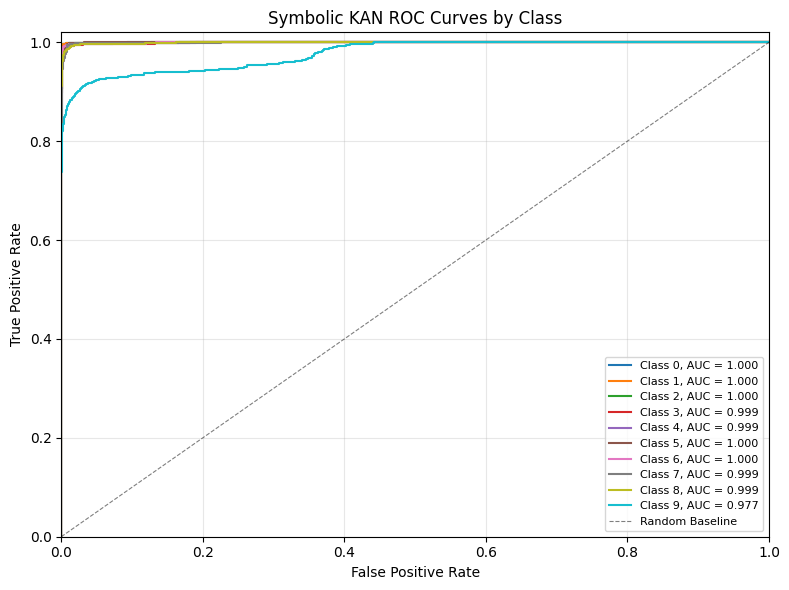


③ 符号回归汇总表


,类别,表达式,复杂度,AUC
0,0,0.13*(0.68*tanh(1.4*x_13 + 0.99) + 0.38*tanh(2.1*x_21 - 0.11) + 0.7*tanh(1.4*x_22 + 0.75) + 0.29*tanh(1.3*x_25 + 0.67) + 0.33*tanh(2.1*x_27 - 0.15) - 0.28*tanh(1.4*x_4 - 1.1) - 1)**2 - 0.024,56,0.9998
1,1,0.22*(-0.0012*x_8 + 0.13*(0.68 - x_12)**2 - 0.54*tanh(1.2*x_17 - 0.31) + 0.25*tanh(2.9*x_25 + 1.5) + 0.29*tanh(2.2*x_28 + 0.5) + 0.5*tanh(0.76*x_5 + 0.85) - 1)**2 - 0.028,52,0.9998
2,2,0.39*(-0.2*(1 - 0.66*x_10)**2 + 0.86*(-0.11*x_2 - 1)**2 + 0.18*tanh(2.9*x_25 - 0.59) + 0.2*tanh(1*x_28 - 0.48) - 0.14*tanh(4.8*x_3 + 0.83) - 0.5*tanh(0.77*x_6 - 0.61) - 1)**2 - 0.027,58,0.9997
3,3,0.14*(-0.72*(1 - 0.44*x_11)**2 - 0.75*tanh(1*x_14 - 0.35) - 0.35*tanh(0.93*x_15 - 0.77) - 0.28*tanh(4.2*x_24 + 0.62) + tanh(0.71*x_6 - 1.4) + 0.85)**2 + 0.0013*(-0.0023*x_8 + 0.24*(0.68 - x_12)**2 - tanh(1.2*x_17 - 0.31) + 0.47*tanh(2.9*x_25 + 1.5) + 0.54*tanh(2.2*x_28 + 0.5) + 0.93*tanh(0.76*x_...,97,0.9992
4,4,0.13*(-0.4*tanh(2.9*x_19 + 1.4) + 0.6*tanh(2.1*x_24 + 0.92) - tanh(0.92*x_26 - 0.47) + 0.91*tanh(0.45*x_9 - 1.1) - 0.18)**2 - 0.015*(-0.0015*x_8 + 0.16*(0.68 - x_12)**2 - 0.64*tanh(1.2*x_17 - 0.31) + 0.3*tanh(2.9*x_25 + 1.5) + 0.34*tanh(2.2*x_28 + 0.5) + 0.6*tanh(0.76*x_5 + 0.85) - 1)**2 - 0.033,90,0.9992
5,5,0.23*(-0.00014*x_8 + 0.1*(-x_21 - 0.44)**2 - 0.29*tanh(1.1*x_10 - 1.1) - tanh(0.56*x_18 + 0.0041) + 0.56*tanh(1.1*x_4 - 0.52) - 0.51)**2 - 0.038,44,0.9997
6,6,-0.048*(0.83*tanh(1.2*x_10 - 1.5) + 0.61*tanh(0.96*x_14 - 0.88) - tanh(0.71*x_27 - 0.88) - 0.31)**2 + 0.1*(-0.15*(-x_11 - 0.2)**2 - tanh(1.9*x_1 + 1.9) + 0.57*tanh(1.4*x_20 - 0.48) + 0.63*tanh(1.7*x_22 + 1.5) - 0.06)**2 + 0.038*(-0.00033*x_8 + 0.21*(-x_16 - 0.57)**2 - 0.51*tanh(1.3*x_21 - 0.12) ...,111,0.9995
7,7,0.33*(0.12*(1 - 0.6*x_7)**2 + 0.47*tanh(3.6*x_11 + 3.2) + 0.48*tanh(1.3*x_16 - 0.27) + 0.23*tanh(1.6*x_23 + 0.98) - 0.18*tanh(3.4*x_28 + 0.76) + tanh(0.36*x_9 - 0.86) + 0.039)**2 - 0.058,55,0.9993
8,8,0.12*(0.83*tanh(1.2*x_10 - 1.5) + 0.61*tanh(0.96*x_14 - 0.88) - tanh(0.71*x_27 - 0.88) - 0.35)**2 - 0.056*(-0.15*(-x_11 - 0.2)**2 - tanh(1.9*x_1 + 1.9) + 0.57*tanh(1.4*x_20 - 0.48) + 0.63*tanh(1.7*x_22 + 1.5) - 0.13)**2 + 0.11*(-0.00033*x_8 + 0.21*(-x_16 - 0.57)**2 - 0.51*tanh(1.3*x_21 - 0.12) -...,111,0.9992
9,9,0.14*(0.0094*x_8 + tanh(1.8*x_27 + 0.57) - 0.59)**2 - 0.017,17,0.9769



汇总表已保存至: D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\outputs\notebooks\kan_symbolic_summary.csv（expr_full 列保留全精度）
平均 AUC (macro)= 0.9972


In [27]:
# ═══════════════════════════════════════════════════════════════
# 公式数值验证 + ROC/AUC + 汇总表
# ═══════════════════════════════════════════════════════════════

from scipy.special import softmax as _softmax

# ── 1. 公式 vs 模型 R² 数值验证 ──
if len(valid_exprs) > 0:
    print('='*60)
    print('① 数值验证：sympy公式 vs KAN forward 输出')
    print('='*60)
    val_df = validate_formula_numerically(export_model, export_formulas, dataset_enhanced, n_sample=500)
    if val_df is not None and len(val_df) > 0:
        display(val_df)
        mean_r2 = val_df['r2'].mean()
        pos_r2 = val_df[val_df['r2'] > 0]['r2'].mean() if (val_df['r2'] > 0).any() else 0
        neg_count = (val_df['r2'] < 0).sum()
        unstable_count = val_df['numerically_unstable'].sum() if 'numerically_unstable' in val_df.columns else 0
        print(f'\n公式-模型一致性:')
        print(f'  平均 R² = {mean_r2:.4f}')
        print(f'  正 R² 平均 = {pos_r2:.4f}')
        print(f'  负 R² 数量 = {neg_count}/{len(val_df)}')
        if unstable_count > 0:
            print(f'  ⚠ 数值不稳定表达式: {unstable_count}/{len(val_df)}')
    else:
        print('数值验证未能完成（公式解析失败）')

# ── 2. 符号化模型测试精度 ──
sym_acc = model_acc_ds(export_model, dataset_enhanced)
print(f'\n符号化模型测试精度: {sym_acc:.4f}')
print(f'原始增强模型精度:   {enhanced_acc:.4f}')
print(f'精度变化:           {sym_acc - enhanced_acc:+.4f}')
print(f'精度保持率:         {sym_acc/enhanced_acc*100:.1f}%')

if sym_acc >= 0.80:
    print('\n✓ 符号化后精度 ≥ 0.80，达标')
elif sym_acc >= 0.70:
    print('\n△ 符号化后精度 0.70~0.80，基本可接受')
elif sym_acc >= enhanced_acc * 0.85:
    print(f'\n△ 精度保持率 ≥ 85%，可接受')
else:
    print('\n⚠ 符号化后精度偏低，建议：')
    print('  1. 调整 Topk和两次目标边数')
    print('  2. 调整 affine_finetune_steps')
    print('  3. 调整 layerwise_finetune_steps')


# ── 3. ROC/AUC 评估（基于符号化模型 forward） ──
print(f'\n{"="*60}')
print('② ROC/AUC 评估（符号化模型）')
print(f'{"="*60}')

# 获取符号化模型的 logits 并转为概率
logits_sym = model_logits(export_model, X_test_sel)
y_prob_sym = _softmax(logits_sym, axis=1)

# 获取 one-hot 测试标签
Y_test_sel = dataset_enhanced['test_label'].detach().cpu().numpy()

# 计算 per-class ROC/AUC
roc_data = compute_multiclass_roc_auc(Y_test_sel, y_prob_sym)

# 绘制 ROC 曲线
class_labels = [str(i) for i in range(n_classes)]
plot_roc_curves(roc_data, class_labels=class_labels,
                title='Symbolic KAN ROC Curves by Class')

# 输出 AUC 概览
auc_vals = [roc_data[c]['auc'] for c in range(n_classes)]
# print(f'\nROC Curves (Per Class):')
# for c in range(n_classes):
#     print(f'  Class {c}: AUC = {roc_data[c]["auc"]:.4f}')
# print(f'  Average AUC (macro): {np.mean(auc_vals):.4f}')

# ── 4. 汇总表：类别 | 表达式(2位有效数字) | 复杂度 | AUC ──
print(f'\n{"="*60}')
print('③ 符号回归汇总表')
print(f'{"="*60}')

# 收集所有类别的表达式（含零/常数）
all_formulas = collect_all_formulas(export_formulas)
# valid_exprs 用于匹配有效表达式
valid_idx_set = {v['index'] for v in valid_exprs}

summary_rows = []
for c in range(n_classes):
    formula_info = next((f for f in all_formulas if f['index'] == c), None)
    if formula_info and formula_info['index'] in valid_idx_set:
        expr_full = formula_info['expr']
        expr_display = format_expr(expr_full, n_digits=2)
        complexity = formula_info['complexity']
    else:
        expr_full = 'N/A (零或常数)'
        expr_display = 'N/A'
        complexity = 0

    auc_val = roc_data[c]['auc']
    summary_rows.append({
        '类别': c,
        '表达式': expr_display,
        '复杂度': complexity,
        'AUC': round(auc_val, 4),
        'expr_full': expr_full,
    })

summary_df = pd.DataFrame(summary_rows)

display_cols = ['类别', '表达式', '复杂度', 'AUC']
with pd.option_context('display.max_colwidth', 300, 'display.max_columns', None):
    display(summary_df[display_cols])

symbolic_summary_path = notebook_output_dir / 'kan_symbolic_summary.csv'
csv_path = save_symbolic_summary(summary_df, csv_path=str(symbolic_summary_path))
print(f'\n汇总表已保存至: {csv_path}（expr_full 列保留全精度）')
print(f'平均 AUC (macro)= {np.mean(auc_vals):.4f}')

## 10) 参数说明文档（外部文档）

参数与调参建议已独立维护：
- `docs/kan_parameters.md`
- `docs/symkan_usage.md`

建议：Notebook 只保留实验逻辑，详细参数语义以文档为准。

## 11) 性能与内存基准（评估链路专题）

目标：量化优化前后评估链路开销。
- 比较 legacy 与 tensor 快路径。
- 观察公式验证首次编译 vs 缓存复用差异。
- 输出耗时、RSS 变化、GPU 峰值显存。

In [28]:
import time
import importlib
import numpy as np
import pandas as pd
import torch

import symkan.core as core
import symkan.core.modeling as core_modeling
import symkan.eval as eval_pkg
import symkan.eval.metrics as eval_metrics

importlib.reload(core_modeling)
importlib.reload(eval_metrics)
importlib.reload(core)
importlib.reload(eval_pkg)

model_acc = core.model_acc
model_acc_ds = core.model_acc_ds
model_acc_ds_fast = getattr(core, "model_acc_ds_fast", core_modeling.model_acc_ds_fast)
validate_formula_numerically = eval_metrics.validate_formula_numerically

try:
    import psutil
except Exception:
    psutil = None


def _rss_mb():
    if psutil is None:
        return np.nan
    return psutil.Process().memory_info().rss / (1024 ** 2)


def benchmark_callable(name, fn, repeat=3, warmup=1):
    for _ in range(max(0, warmup)):
        fn()

    times = []
    rss_deltas = []
    gpu_peaks = []

    for _ in range(repeat):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        rss_before = _rss_mb()
        t0 = time.perf_counter()
        out = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        dt = time.perf_counter() - t0
        rss_after = _rss_mb()

        times.append(dt)
        rss_deltas.append(rss_after - rss_before if np.isfinite(rss_before) and np.isfinite(rss_after) else np.nan)
        gpu_peaks.append(torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else np.nan)

    return {
        "name": name,
        "time_mean_s": float(np.mean(times)),
        "time_std_s": float(np.std(times)),
        "rss_delta_mean_mb": float(np.nanmean(rss_deltas)) if len(rss_deltas) else np.nan,
        "gpu_peak_mean_mb": float(np.nanmean(gpu_peaks)) if len(gpu_peaks) else np.nan,
        "last_output": out,
    }


# ---- B1: 评估链路对比（legacy vs fast vs current API）----
X_np = dataset_enhanced["test_input"].detach().cpu().numpy()
y_np = np.argmax(dataset_enhanced["test_label"].detach().cpu().numpy(), axis=1)

bench_rows = []
bench_rows.append(benchmark_callable("legacy_numpy_path", lambda: model_acc(enhanced_model, X_np, y_np)))
bench_rows.append(benchmark_callable("fast_tensor_path", lambda: model_acc_ds_fast(enhanced_model, dataset_enhanced)))
bench_rows.append(benchmark_callable("model_acc_ds_current", lambda: model_acc_ds(enhanced_model, dataset_enhanced)))

# ---- C2: 公式验证缓存对比（首次/二次调用）----
formula_payload = None
if "all_formulas" in globals() and all_formulas is not None:
    formula_payload = all_formulas
elif "export_formulas" in globals() and export_formulas is not None:
    formula_payload = export_formulas
elif "export_result" in globals() and isinstance(export_result, dict) and export_result.get("formulas") is not None:
    formula_payload = export_result.get("formulas")

if formula_payload is not None:
    target_model = export_model if "export_model" in globals() and export_model is not None else enhanced_model
    bench_rows.append(benchmark_callable("validate_formula_first", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))
    bench_rows.append(benchmark_callable("validate_formula_cached", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))

benchmark_df = pd.DataFrame([{k: v for k, v in row.items() if k != "last_output"} for row in bench_rows])
benchmark_df

,name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb
0,legacy_numpy_path,0.399449,0.031882,0.0,NaN
1,fast_tensor_path,0.319117,0.002391,0.0,NaN
2,model_acc_ds_current,0.341532,0.012562,0.0,NaN
3,validate_formula_first,0.000054,0.000000,0.0,NaN
4,validate_formula_cached,0.000031,0.000000,0.0,NaN


### 11.1) 自动多轮统计（稳健结论）

- 对基准项做多轮独立测试，降低单轮波动影响。
- 输出 `multi_round_raw` 与 `multi_round_summary`。
- 建议论文使用多轮均值 ± 标准差报告。

In [29]:
import pandas as pd
import symkan.eval.metrics as eval_metrics

# 若前一单元未运行，尽量自动补齐依赖
if "benchmark_callable" not in globals():
    raise RuntimeError("请先运行上一单元（性能与内存对比基准）以初始化 benchmark_callable 和相关变量。")

rounds = 3
all_round_rows = []

for rid in range(1, rounds + 1):
    round_rows = []

    # B1: 评估链路
    round_rows.append(benchmark_callable("legacy_numpy_path", lambda: model_acc(enhanced_model, X_np, y_np), repeat=3, warmup=1))
    round_rows.append(benchmark_callable("fast_tensor_path", lambda: model_acc_ds_fast(enhanced_model, dataset_enhanced), repeat=3, warmup=1))
    round_rows.append(benchmark_callable("model_acc_ds_current", lambda: model_acc_ds(enhanced_model, dataset_enhanced), repeat=3, warmup=1))

    # C2: 公式缓存（如果公式可用）
    if formula_payload is not None:
        if hasattr(eval_metrics, "_LAMBDA_CACHE") and isinstance(eval_metrics._LAMBDA_CACHE, dict):
            eval_metrics._LAMBDA_CACHE.clear()
        round_rows.append(benchmark_callable("validate_formula_first", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))
        round_rows.append(benchmark_callable("validate_formula_cached", lambda: validate_formula_numerically(target_model, formula_payload, dataset_enhanced, n_sample=500), repeat=1, warmup=0))

    for row in round_rows:
        row_clean = {k: v for k, v in row.items() if k != "last_output"}
        row_clean["round"] = rid
        all_round_rows.append(row_clean)

multi_round_raw = pd.DataFrame(all_round_rows)

multi_round_summary = (
    multi_round_raw
    .groupby("name", as_index=False)
    .agg(
        time_mean_s=("time_mean_s", "mean"),
        time_std_s=("time_mean_s", "std"),
        rss_delta_mean_mb=("rss_delta_mean_mb", "mean"),
        gpu_peak_mean_mb=("gpu_peak_mean_mb", "mean"),
    )
)

# 相对 legacy 的耗时降幅（正值表示更快）
if (multi_round_summary["name"] == "legacy_numpy_path").any():
    legacy_t = float(multi_round_summary.loc[multi_round_summary["name"] == "legacy_numpy_path", "time_mean_s"].iloc[0])
    multi_round_summary["vs_legacy_time_reduction_pct"] = (legacy_t - multi_round_summary["time_mean_s"]) / legacy_t * 100.0

# 相对 validate_formula_first 的耗时降幅（仅公式验证项）
if (multi_round_summary["name"] == "validate_formula_first").any():
    first_t = float(multi_round_summary.loc[multi_round_summary["name"] == "validate_formula_first", "time_mean_s"].iloc[0])
    mask_formula = multi_round_summary["name"].isin(["validate_formula_first", "validate_formula_cached"])
    multi_round_summary.loc[mask_formula, "vs_first_validate_reduction_pct"] = (
        (first_t - multi_round_summary.loc[mask_formula, "time_mean_s"]) / first_t * 100.0
    )

multi_round_summary = multi_round_summary.sort_values("time_mean_s", ascending=True).reset_index(drop=True)

print("multi_round_raw (每轮明细):")
display(multi_round_raw)
print("\nmulti_round_summary (3轮汇总):")
display(multi_round_summary)

multi_round_raw (每轮明细):


,name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb,round
0,legacy_numpy_path,0.335161,0.008459,0.0,NaN,1
1,fast_tensor_path,0.339757,0.007923,0.0,NaN,1
2,model_acc_ds_current,0.294403,0.003823,0.0,NaN,1
3,validate_formula_first,0.000061,0.000000,0.0,NaN,1
4,validate_formula_cached,0.000031,0.000000,0.0,NaN,1
5,legacy_numpy_path,0.311604,0.006402,0.0,NaN,2
6,fast_tensor_path,0.310678,0.012040,0.0,NaN,2
7,model_acc_ds_current,0.294634,0.004062,0.0,NaN,2
8,validate_formula_first,0.000052,0.000000,0.0,NaN,2
9,validate_formula_cached,0.000029,0.000000,0.0,NaN,2



multi_round_summary (3轮汇总):


,name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb,vs_legacy_time_reduction_pct,vs_first_validate_reduction_pct
0,validate_formula_cached,0.000030,0.000001,0.0,NaN,99.990803,47.997678
1,validate_formula_first,0.000057,0.000005,0.0,NaN,99.982314,0.000000
2,model_acc_ds_current,0.307043,0.021694,0.0,NaN,5.448558,NaN
3,legacy_numpy_path,0.324737,0.012010,0.0,NaN,0.000000,NaN
4,fast_tensor_path,0.333571,0.020512,0.0,NaN,-2.720404,NaN


### 11.2) 论文导出表（CSV）

本节生成标准化导出：
- 原始明细（raw）
- 中文汇总（论文正文）
- 英文汇总（附录/国际化）

至此，实验与性能两条线都可复现并可直接用于论文图表。

In [30]:
from pathlib import Path

if "multi_round_raw" not in globals() or "multi_round_summary" not in globals():
    raise RuntimeError("请先运行上一单元（自动3轮汇总）生成 multi_round_raw 与 multi_round_summary。")

report_dir = notebook_output_dir
raw_csv_path = report_dir / "benchmark_multi_round_raw.csv"
cn_csv_path = report_dir / "benchmark_multi_round_summary_cn.csv"
en_csv_path = report_dir / "benchmark_multi_round_summary_en.csv"

# 英文汇总（标准字段）
summary_en = multi_round_summary.copy()
summary_en = summary_en.rename(
    columns={
        "name": "metric_name",
        "time_mean_s": "time_mean_s",
        "time_std_s": "time_std_s",
        "rss_delta_mean_mb": "rss_delta_mean_mb",
        "gpu_peak_mean_mb": "gpu_peak_mean_mb",
        "vs_legacy_time_reduction_pct": "vs_legacy_time_reduction_pct",
        "vs_first_validate_reduction_pct": "vs_first_validate_reduction_pct",
    }
)

# 中文汇总（论文友好字段）
summary_cn = multi_round_summary.copy().rename(
    columns={
        "name": "指标项",
        "time_mean_s": "平均耗时(秒)",
        "time_std_s": "耗时标准差(秒)",
        "rss_delta_mean_mb": "RSS平均变化(MB)",
        "gpu_peak_mean_mb": "GPU峰值显存均值(MB)",
        "vs_legacy_time_reduction_pct": "相对legacy耗时降幅(%)",
        "vs_first_validate_reduction_pct": "相对首次公式验证降幅(%)",
    }
)

# 指标名中英文映射
name_map_cn = {
    "legacy_numpy_path": "旧评估路径（NumPy往返）",
    "fast_tensor_path": "新评估路径（Tensor快路径）",
    "model_acc_ds_current": "当前默认评估接口",
    "validate_formula_first": "公式验证（首次编译）",
    "validate_formula_cached": "公式验证（缓存复用）",
}
summary_cn["指标项"] = summary_cn["指标项"].map(lambda x: name_map_cn.get(x, x))

# 保留可读的小数位
for df in (summary_en, summary_cn):
    for col in df.columns:
        if df[col].dtype.kind in ("f", "c"):
            df[col] = df[col].round(6)

multi_round_raw.to_csv(raw_csv_path, index=False, encoding="utf-8-sig")
summary_cn.to_csv(cn_csv_path, index=False, encoding="utf-8-sig")
summary_en.to_csv(en_csv_path, index=False, encoding="utf-8-sig")

print("已导出:")
print(f"- {raw_csv_path}")
print(f"- {cn_csv_path}")
print(f"- {en_csv_path}")

print("\n中文汇总预览:")
display(summary_cn)
print("\n英文汇总预览:")
display(summary_en)

已导出:
- D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\outputs\notebooks\benchmark_multi_round_raw.csv
- D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\outputs\notebooks\benchmark_multi_round_summary_cn.csv
- D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\outputs\notebooks\benchmark_multi_round_summary_en.csv

中文汇总预览:


,指标项,平均耗时(秒),耗时标准差(秒),RSS平均变化(MB),GPU峰值显存均值(MB),相对legacy耗时降幅(%),相对首次公式验证降幅(%)
0,公式验证（缓存复用）,0.000030,0.000001,0.0,NaN,99.990803,47.997678
1,公式验证（首次编译）,0.000057,0.000005,0.0,NaN,99.982314,0.000000
2,当前默认评估接口,0.307043,0.021694,0.0,NaN,5.448558,NaN
3,旧评估路径（NumPy往返）,0.324737,0.012010,0.0,NaN,0.000000,NaN
4,新评估路径（Tensor快路径）,0.333571,0.020512,0.0,NaN,-2.720404,NaN



英文汇总预览:


,metric_name,time_mean_s,time_std_s,rss_delta_mean_mb,gpu_peak_mean_mb,vs_legacy_time_reduction_pct,vs_first_validate_reduction_pct
0,validate_formula_cached,0.000030,0.000001,0.0,NaN,99.990803,47.997678
1,validate_formula_first,0.000057,0.000005,0.0,NaN,99.982314,0.000000
2,model_acc_ds_current,0.307043,0.021694,0.0,NaN,5.448558,NaN
3,legacy_numpy_path,0.324737,0.012010,0.0,NaN,0.000000,NaN
4,fast_tensor_path,0.333571,0.020512,0.0,NaN,-2.720404,NaN


## 12) 并行策略快速对照（速度专题）

目标：在保持分层符号化约束下，比较 `auto/off/thread` 的速度差异。
- 输出 `wall_time_s` 与 `symbolic_time_s`。
- 记录 `final_acc/final_n_edge` 用于“速度-质量”折中分析。
- 结果导出为 `outputs/notebooks/benchmark_symbolic_parallel_quick.csv`。

In [31]:
# 快速并行策略对照（仅符号化阶段）
import time
import pandas as pd
import torch

if 'enhanced_model' not in globals() or 'dataset_enhanced' not in globals():
    raise RuntimeError('请先运行第 15 和第 19 个代码单元，确保 enhanced_model 与 dataset_enhanced 已就绪。')

# 根据当前边数自适应一个较温和的目标，避免基准过慢
_edge_now = int(get_n_edge(enhanced_model))
_target_quick = max(40, min(80, _edge_now))

bench_modes = [
    {'name': 'auto',   'parallel_mode': 'auto',   'parallel_workers': None},
    {'name': 'off',    'parallel_mode': 'off',    'parallel_workers': 1},
    {'name': 'thread4','parallel_mode': 'thread', 'parallel_workers': 4},
]

# CUDA 下 thread4 通常收益有限，仍保留用于验证
if torch.cuda.is_available():
    print('检测到 CUDA：将同时给出 auto/off/thread4 对照（thread4 可能与 auto 接近）。')
else:
    print('当前为 CPU：thread4 通常会带来更明显收益。')

parallel_bench_rows = []
for cfg in bench_modes:
    t0 = time.perf_counter()
    out = symbolize_pipeline(
        enhanced_model,
        dataset_enhanced,
        target_edges=_target_quick,
        max_prune_rounds=8,
        lib=None,
        lib_hidden=_LIB_HIDDEN,
        lib_output=_LIB_OUTPUT,
        weight_simple=0.10,
        finetune_steps=20,
        finetune_lr=0.0005,
        layerwise_finetune_steps=40,
        affine_finetune_steps=0,
        batch_size=BATCH_SIZE,
        # 与主流程一致：低风险提速开关
        prune_eval_interval=2,
        prune_attr_sample_adaptive=True,
        prune_attr_sample_min=512,
        prune_attr_sample_max=1536,
        heavy_ft_early_stop_patience=1,
        heavy_ft_early_stop_min_delta=5e-4,
        collect_timing=True,
        verbose=False,
        parallel_mode=cfg['parallel_mode'],
        parallel_workers=cfg['parallel_workers'],
        parallel_min_tasks=16,
    )
    wall = time.perf_counter() - t0
    t_stats = out.get('timing', {})
    sym_t = t_stats.get('symbolic_total_seconds', float('nan'))
    parallel_bench_rows.append({
        'mode': cfg['name'],
        'parallel_mode': cfg['parallel_mode'],
        'parallel_workers_effective': out.get('sym_stats', {}).get('parallel_workers', None),
        'wall_time_s': float(wall),
        'symbolic_time_s': float(sym_t) if sym_t == sym_t else float('nan'),
        'final_acc': float(out.get('final_acc', float('nan'))),
        'final_n_edge': int(out.get('final_n_edge', -1)),
    })

parallel_bench_df = pd.DataFrame(parallel_bench_rows).sort_values('wall_time_s').reset_index(drop=True)
if len(parallel_bench_df) > 0:
    base = float(parallel_bench_df.loc[parallel_bench_df['mode'] == 'off', 'wall_time_s'].iloc[0]) if (parallel_bench_df['mode'] == 'off').any() else float(parallel_bench_df['wall_time_s'].iloc[0])
    parallel_bench_df['vs_off_speedup_x'] = base / parallel_bench_df['wall_time_s']

print('并行策略快速对照：')
display(parallel_bench_df)

# 可选：导出到 CSV 便于论文记录
parallel_quick_path = notebook_output_dir / 'benchmark_symbolic_parallel_quick.csv'
parallel_bench_df.to_csv(parallel_quick_path, index=False, encoding='utf-8-sig')
print(f'已导出: {parallel_quick_path}')

当前为 CPU：thread4 通常会带来更明显收益。


| train_loss: 8.36e-02 | test_loss: 9.32e-02 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 64.50it
| train_loss: 5.04e-02 | test_loss: 9.29e-02 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 81.15
| train_loss: 1.67e-01 | test_loss: 1.34e-01 | reg: 3.27e+00 | : 100%|█| 20/20 [00:04<00:00,  4.78it
| train_loss: 1.18e-01 | test_loss: 8.49e-02 | reg: 3.48e+00 | : 100%|█| 20/20 [00:04<00:00,  4.90it
| train_loss: 1.16e-01 | test_loss: 9.99e-02 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 58.39it
| train_loss: 5.04e-02 | test_loss: 9.29e-02 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:00, 80.77
| train_loss: 7.99e-02 | test_loss: 7.98e-02 | reg: 3.76e+00 | : 100%|█| 20/20 [00:03<00:00,  5.10it
| train_loss: 9.83e-02 | test_loss: 1.09e-01 | reg: 3.93e+00 | : 100%|█| 20/20 [00:03<00:00,  5.12it
| train_loss: 1.16e-01 | test_loss: 9.99e-02 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 54.93it
| train_loss: 5.04e-02 | test_loss: 9.29e-02 | reg: 0.00e+00 | : 100%|█| 100/100 [00:01<00:

并行策略快速对照：


,mode,parallel_mode,parallel_workers_effective,wall_time_s,symbolic_time_s,final_acc,final_n_edge,vs_off_speedup_x
0,thread4,thread,1,32.204916,28.462697,0.9805,70,1.024961
1,off,off,1,33.008773,29.014781,0.9805,70,1.000000
2,auto,auto,1,33.323307,29.357463,0.9805,70,0.990561


已导出: D:\chenpeng\Documents\学习\数学\毕业论文\symkan-experiments\outputs\notebooks\benchmark_symbolic_parallel_quick.csv
